In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import math as m

In [2]:
# import tqdm
import kagglehub, os

c:\Users\Miguel Almeida\envs\sw1pers_l_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
key = "energy_consumption"

FILE = "tetuan-city-power-consumption"

path = kagglehub.dataset_download(f"gmkeshav/{FILE}")

print("Path to dataset files:", path)

files = os.listdir(path)
print("Downloaded files:", files)
df = pd.read_csv(os.path.join(path, files[0]))
df.info()

# store files locally
# df.to_parquet(f'{FILE}.parquet')

Path to dataset files: C:\Users\Miguel Almeida\.cache\kagglehub\datasets\gmkeshav\tetuan-city-power-consumption\versions\1
Downloaded files: ['Tetuan City power consumption.csv']
<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  str    
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), str(1)
memory usage: 3.6 MB


In [4]:
# t_1, ..., t_S

# Set the period
period = 144    # S / L

L = 40

instances = period*L    # S = 144 * L

column = 'Zone 1 Power Consumption'

# Read from stored files
# df = pd.read_parquet(f'{FILE}.parquet')

dates_energy = df["DateTime"].values[0:instances]

energy_consumption = df[column].values[0:instances]

In [5]:
if key == "energy_consumption":
    ts = energy_consumption
    dates = dates_energy

In [6]:
#requires "pip install -e ." from root directory

import sw1pers_l
from sw1pers_l.core import SW1PerS, SW1PerS_L

Factor = 4

window_size = len(time_series)/30
window_stride = window_size/8

Finding best parameters...



100%|██████████| 235/235 [00:46<00:00,  5.02it/s]



Forming point clouds...



100%|██████████| 235/235 [00:05<00:00, 40.31it/s]



Forming persistence diagrams...



100%|██████████| 235/235 [01:07<00:00,  3.51it/s]


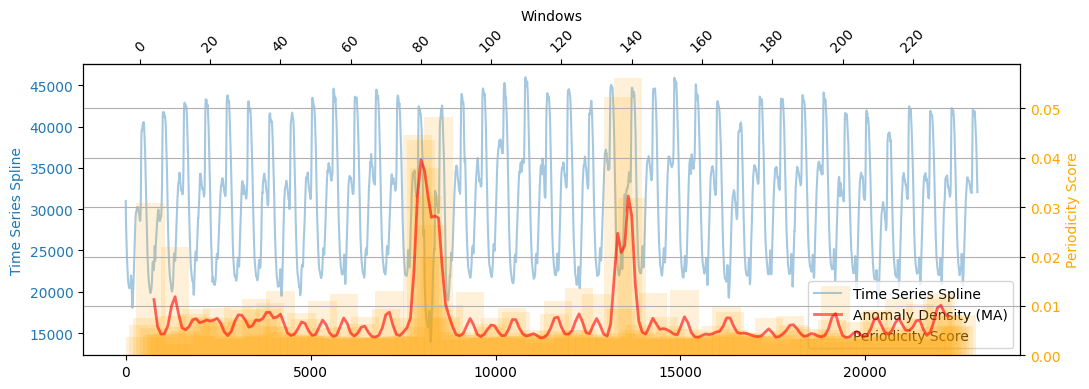

In [7]:
scores = SW1PerS_L(ts, rolling_size = 3, factor = 4, choose_hyper_param=True)

# algorithm comparison

In [8]:
from sw1pers_l.data_processing.cubic_spline import make_spline
from sw1pers_l.data_processing.moving_average import moving_avg

In [9]:
# prepare spline just as in main algorithm

test_factor = 4

test_t_ma, test_ma = moving_avg(ts, rolling_size=3)

test_t_fine, test_finer_spline = make_spline(test_t_ma, test_ma, test_factor*len(ts))

Factor = 4



In [10]:
from sw1pers_l.time_series.sliding_windows import make_sliding_windows

In [11]:
from sw1pers_l.sw1pers_scores.plot import plot_scores_comparison
from sw1pers_l.sw1pers_scores.plot import plot_score_landscape

In [12]:
# must match with input in main algorithm

window_size = len(test_finer_spline)//30
window_stride = window_size//8
rolling_size_scores = window_size//window_stride

ts_windows = make_sliding_windows(test_finer_spline.reshape(len(test_finer_spline), ), window_size, window_stride)

freqs = np.linspace(1/window_size, 1/(window_size*0.6), 100)    # create an array of frequencies to be tested

## JTK

In [16]:
from scipy.stats import kendalltau    # import ingredient for JTK algorithm

In [17]:
def jtk_cycle_score(x, time=None, periods=np.arange(16, 36), n_phases=24):
    x = np.asarray(x)

    if time is None:
        time = np.arange(len(x))
    else:
        time = np.asarray(time)

    best_score = -np.inf     # compare abs(tau)
    best_tau = None
    best_period = None
    best_phase = None

    for P in periods:
        phases = np.linspace(0, P, n_phases, endpoint=False)

        for phi in phases:
            ref = np.cos((2*np.pi/P) * (time - phi))

            tau, _ = kendalltau(x, ref, nan_policy='omit')

            # Skip invalid tau
            if tau is None or np.isnan(tau):
                continue

            score = np.abs(tau)
            if score > best_score:
                best_score = score
                best_tau = tau
                best_period = P
                best_phase = phi

    return best_tau, best_period, best_phase

In [18]:
jtk_scores=[]

for i, window in enumerate(ts_windows):
    y_axis = window
    x_axis = np.arange(len(window))
    tau, _, _ = jtk_cycle_score(y_axis, x_axis, periods = np.arange(int(window_size*0.6), int(window_size*1)), n_phases=2)   # evaluate 2 phases, can increase
    jtk_scores.append(tau)

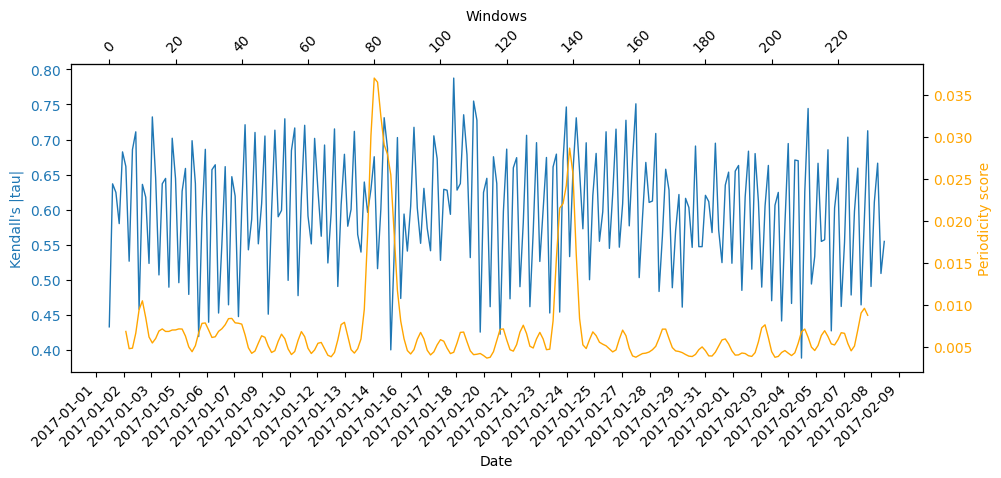

In [19]:
plot_scores_comparison(scores[:len(jtk_scores)], np.abs(jtk_scores), window_size, window_stride, dates, factor = test_factor, score_rolling_size=10,is_score_windowed=True, label_msg="Kendall's |tau|")

## Lomb-Scargle Periodogram

In [18]:
#pip install astropy

In [13]:
from astropy.timeseries import LombScargle    # import lomb-scargle

In [14]:
lomb_scargle_scores=[]

for i, window in enumerate(ts_windows):
    y_axis = window
    x_axis = np.arange(len(window))
    power = LombScargle(x_axis, y_axis).power(freqs)
    lomb_scargle_scores.append(np.max(power))

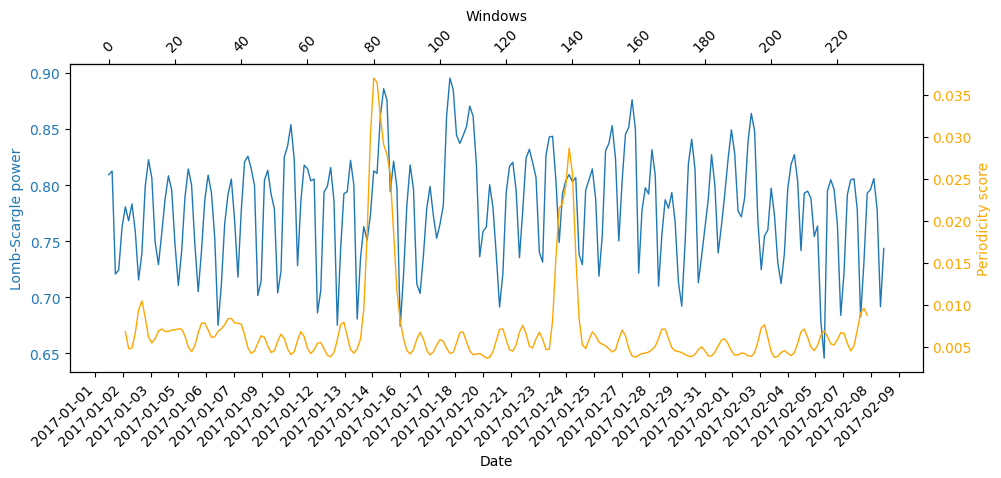

In [15]:
plot_scores_comparison(scores[:len(lomb_scargle_scores)], lomb_scargle_scores, window_size, window_stride, dates, factor = test_factor, score_rolling_size=10,sec_score_rolling_size=1, is_score_windowed=True, label_msg = "Lomb-Scargle power")

## LOF (local outlier factor)

In [20]:
from pyod.models.lof import LOF

In [21]:
def run_lof(ts, window_size=24, n_neighbors=20):
    X = make_sliding_windows(ts, window_size, window_stride)

    clf = LOF(
        n_neighbors=n_neighbors,
        contamination=0.05
    )

    clf.fit(X)

    scores = clf.decision_scores_

    # map back to timeline
    ts_scores = np.zeros(len(ts))
    ts_scores[window_size - 1::window_stride] = scores

    return ts_scores

In [22]:
#compute LOF scores
lof_scores = run_lof(test_finer_spline, window_size=window_size)   # needs sliding_windows function

#filter out zeros
nonzero_lof_scores=[]
for num in lof_scores:
    if num>0.1:
        nonzero_lof_scores.append(num)

In [23]:
from sw1pers_l.sw1pers_scores._density import density

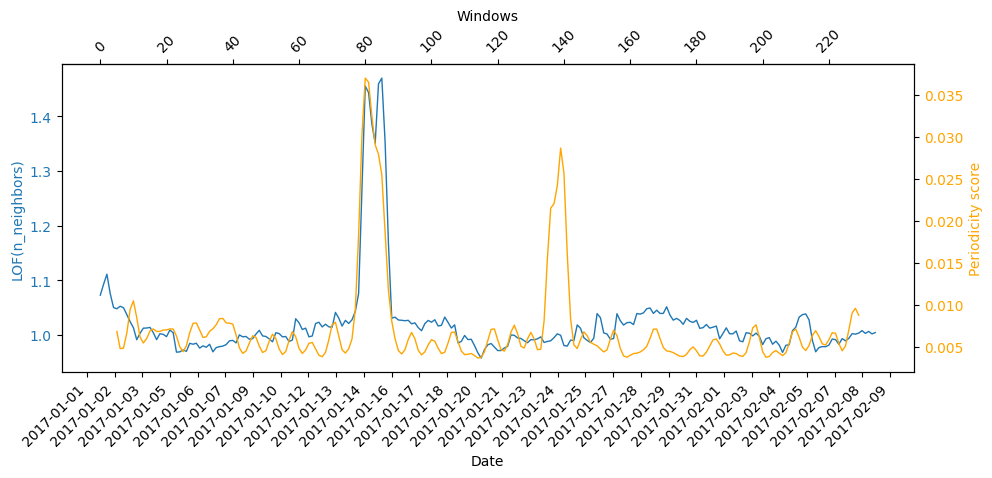

In [24]:
# standard --> rolling_size_scores = window_size/window_stride

plot_scores_comparison(scores[:len(nonzero_lof_scores)], nonzero_lof_scores, window_size, window_stride, dates, factor = test_factor, score_rolling_size=10, is_score_windowed=True, label_msg = "LOF(n_neighbors)")

## Isolation Forest

In [25]:
import pyod

In [26]:
from pyod.models.iforest import IForest
from sw1pers_l.windows.make_emb_ts import make_embedded_ts

In [27]:
emb_ts, _, _ = make_embedded_ts(test_finer_spline)

clf = IForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

clf.fit(emb_ts)

scores_isolation = clf.decision_scores_

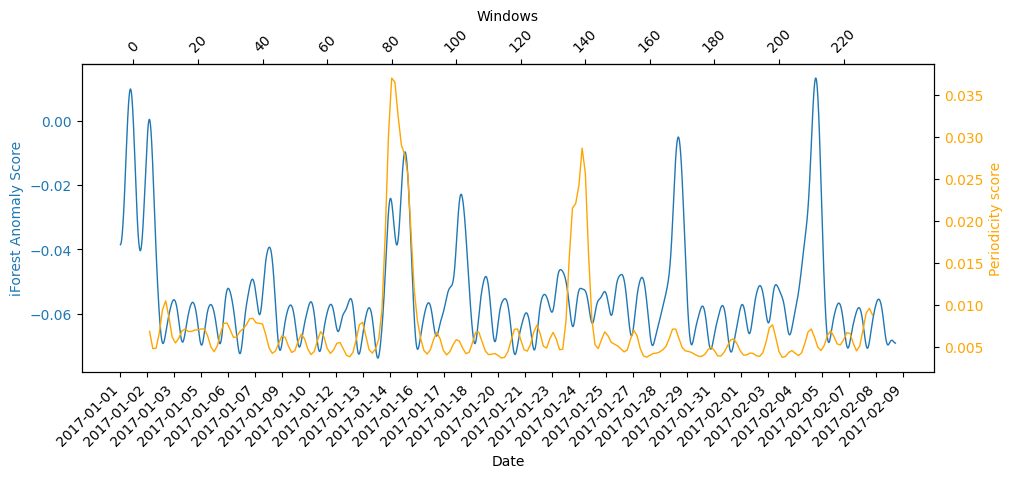

In [ ]:
plot_scores_comparison(scores, scores_isolation, window_size, window_stride, dates, factor = test_factor, score_rolling_size=10, sec_score_rolling_size=window_size, is_score_windowed=False, label_msg = "iForest anomaly score")

## COPOD

In [34]:
from pyod.models.copod import COPOD

In [35]:
def window_statistics(ts, window):
    X = []
    for i in range(len(ts) - window + 1):
        w = ts[i:i+window]
        X.append([
            np.mean(w),
            np.std(w),
            np.min(w),
            np.max(w),
            w[-1] - w[0]   # trend
        ])
    return np.array(X)

X = window_statistics(test_finer_spline, window_size)

clf = COPOD()
clf.fit(X)

scores_copod = clf.decision_scores_

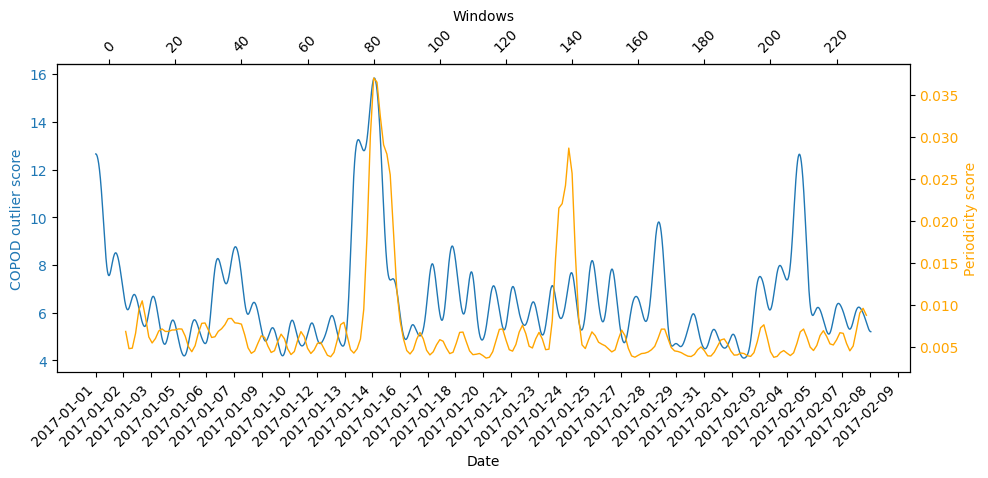

In [40]:
plot_scores_comparison(scores, scores_copod, window_size, window_stride, dates, factor = test_factor, score_rolling_size=10, sec_score_rolling_size=window_size, label_msg = "COPOD outlier score")